In [21]:
import pandas as pd
import pymc as pm
import matplotlib.pyplot as plt
import numpy as np
import arviz as az
import japanize_matplotlib

In [6]:
data

,Rk,Player,Age,Team,Lg,AB,H,BA_observed
0,1,James Wood,23,WSN,NL,326,84,0.257669
1,2,Taylor Ward,32,BAL,AL,316,81,0.256329
2,3,Gunnar Henderson,25,BAL,AL,349,77,0.220630
3,4,Nick Kurtz,23,ATH,AL,301,84,0.279070
4,5,Alex Bregman,32,CHC,NL,322,77,0.239130
...,...,...,...,...,...,...,...,...
169,170,Mark Vientos,26,NYM,NL,226,48,0.212389
170,171,Ronald Acuna Jr.,28,ATL,NL,195,49,0.251282
171,172,Rhys Hoskins,33,CLE,AL,192,35,0.182292
172,173,Jesus Sanchez,28,TOR,AL,215,59,0.274419


In [7]:
data = pd.read_csv("../data/mlb2026_batting_clean.csv")

In [9]:
AB = data["AB"].values
H = data["H"].values
n_players = len(data)

with pm.Model() as bb_model:
    mu = pm.Beta("mu", alpha=4, beta=12)
    kappa = pm.Exponential("kappa", lam=0.01)
    alpha = pm.Deterministic("alpha", mu * kappa)
    beta =  pm.Deterministic("beta", (1 - mu) * kappa)

    p = pm.Beta("p", alpha=alpha, beta=beta, shape=n_players)

    H_obs = pm.Binomial("H_obs", n=AB, p=p, observed=H)

    idata = pm.sample(tune=2000, draw=2000, chain=4,random_seed=42)
    
    



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, kappa, p]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 3 seconds.


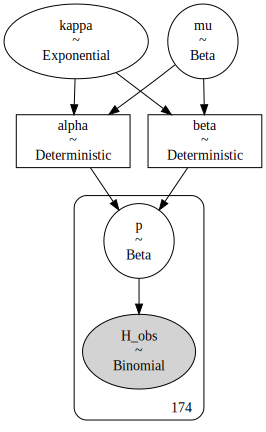

In [15]:
pm.model_to_graphviz(bb_model)

Sampling: [H_obs, kappa, mu, p]


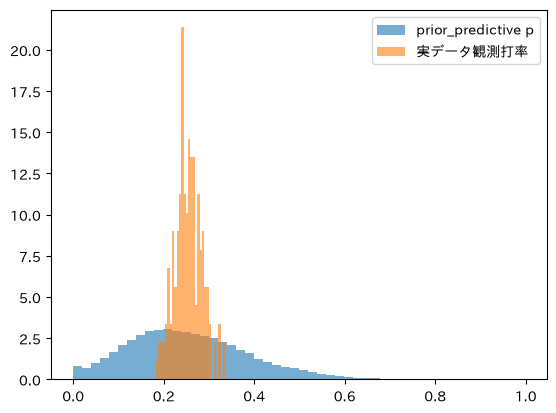

In [25]:
#Prior predictive check
with bb_model:
    prior = pm.sample_prior_predictive(draws=500, random_seed=42)

p_prior = prior.prior["p"].values.flatten()
plt.hist(p_prior, bins=50, density=True, alpha=0.6, label="prior_predictive p")
plt.hist(data["BA_observed"], bins=30, density=True, alpha=0.6, label="実データ観測打率")
plt.legend()
plt.savefig("../img/bb_prior_check.png", dpi=100)


In [24]:
az.summary(idata, var_names=["mu", "kappa"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.25467,0.00248,0.25,0.26,2503,2443,1.00,4.9e-05,3.5e-05
kappa,6e+02,140,370,810,733,831,1.01,5.4,4.6


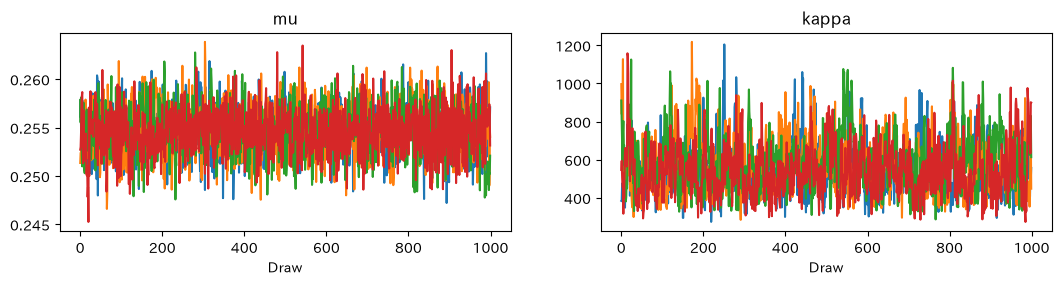

In [23]:
az.plot_trace(idata, var_names=["mu", "kappa"])

In [19]:
idata.sample_stats.diverging.sum().item()

0

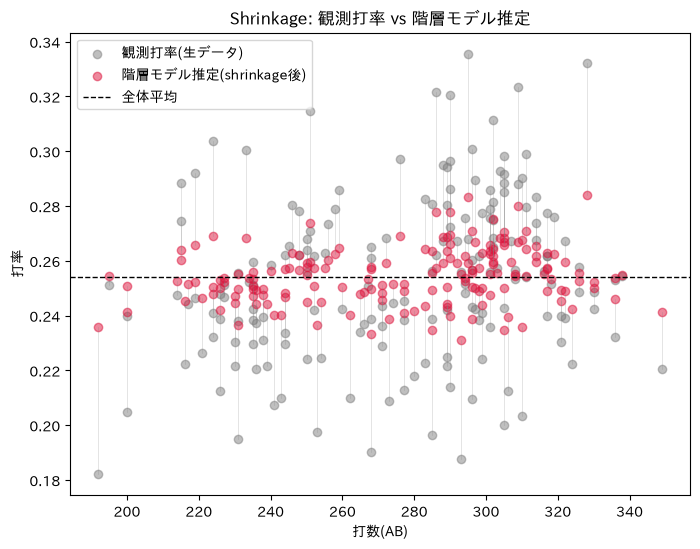

In [29]:
p_post_mean = idata.posterior["p"].mean(dim=("chain", "draw")).values

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(data["AB"], data["BA_observed"], alpha=0.5, label="観測打率(生データ)", color="gray")
ax.scatter(data["AB"], p_post_mean, alpha=0.5, label="階層モデル推定(shrinkage後)", color="crimson")

for i in range(n_players):
    ax.plot([data["AB"].iloc[i]]*2, [data["BA_observed"].iloc[i], p_post_mean[i]],color="gray", lw=0.5, alpha=0.3)

ax.axhline(data["BA_observed"].mean(), color="black", ls="--", lw=1, label="全体平均")
ax.set_xlabel("打数(AB)")
ax.set_ylabel("打率")
ax.legend()
ax.set_title("Shrinkage: 観測打率 vs 階層モデル推定")
plt.savefig("../img/bb_shrinkage.png", dpi=100)            

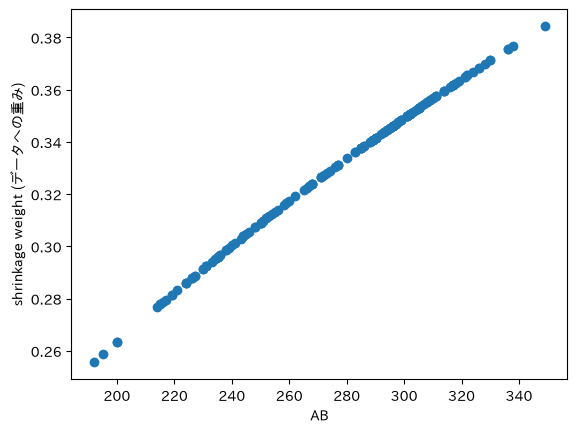

In [31]:
w = data["AB"].values / (data["AB"].values + idata.posterior["kappa"].mean().item())
plt.scatter(data["AB"], w)
plt.xlabel("AB"); plt.ylabel("shrinkage weight (データへの重み)")
plt.savefig("../img/shrinkage_weight.png", dpi=100)

# MLB 2026 打率 階層ベイズ(Beta-Binomial)モデル セッションサマリー

## 目的

MLB 2026シーズン(7月8日時点、n=174選手)の打撃成績を対象に、階層ベイズ(Beta-Binomialモデル)で各選手の「真の打撃実力」を推定する。これまでの時系列モデル(SV、MSM)とは異なり、**時間方向の依存を持たない横断データ**でのグルーピング構造(partial pooling)を扱う、初めての題材。

---

## データ

- baseball-reference.comの2026年打撃成績ページから取得(`pybaseball`、`pandas.read_html`、公式APIいずれでも再現可能)
- n=174選手、打数(AB) 192〜349、打率 0.182〜0.336
- シーズン中盤〜終盤のため、選手間の打数レンジは比較的狭い(最大/最小で約1.8倍)

## モデル構造

$$H_i \sim \text{Binomial}(AB_i,\ p_i), \qquad p_i \sim \text{Beta}(\alpha,\beta)$$
$$\alpha=\mu\kappa,\quad \beta=(1-\mu)\kappa, \qquad \mu\sim\text{Beta}(4,12),\quad \kappa\sim\text{Exponential}(0.01)$$

- **階層性の所在**: $p_i$の事前分布を規定する$\mu$(リーグ平均打率)・$\kappa$(集中度=実力差の逆数)自体を、174選手全員のデータから同時推定する構造。これが「完全独立」でも「全員同一」でもない部分プーリング(partial pooling)を生み、shrinkage(観測打率が少数データの選手ほど全体平均へ引き寄せられる効果)の直接の原因になる。
- $\mu,\kappa$の再パラメータ化(平均・集中度)は、Beta分布の$(\alpha,\beta)$に直接事前分布を置くより解釈しやすいための定石。

## 設計上のつまずきと修正

初期実装案の主な誤り:
1. `mu`に`HalfNormal`を使用 → $(0,1)$に収まらない。`Beta`分布に修正。
2. `kappa`に`Binomial`を使用 → 連続パラメータに離散分布を当てる誤り。`Exponential`に修正。
3. `p = pm.Beta(...)`で`shape`未指定 → 選手ごとの$p_i$にならずスカラー1つに縮退。`shape=n_players`を追加。

$\kappa$の事前分布スケール決定の勘所: $\kappa=\alpha+\beta$は「事前分布が何打席分のデータに相当する強さを持つか」の目安になる。個々の選手の打数(192〜349)と同オーダーかそれ以下に事前分布のスケールを合わせることで、データが事前分布を圧倒できる余地を残す設計とした(`Exponential(lam=0.01)`, 事前平均100)。

## 結果

- $\mu\approx0.2547$(sd=0.0025)、$\kappa\approx600$(sd=140、89%区間[370,810])
- 診断: r_hat 1.00–1.01、divergences=0、トレースプロット上チェーンの分離なし
- **$\kappa$の事後平均(600)は事前平均(100)から約6倍乖離** → 事前分布ではなくデータ自体が$\kappa$の値を強く支持している証拠

### Shrinkageの検証

観測打率 vs モデル推定値の散布図で、shrinkageは確認できたが、**「打数が少ない選手だけが大きく動く」という教科書的なコントラストは弱め**だった。shrinkage weight $w_i=AB_i/(AB_i+\kappa)$を計算したところ、$w_i$は0.25〜0.38程度で、$AB_i$に対してほぼ線形に増加する滑らかな関係になっており、全選手が相応の強さでshrinkageを受けていることを確認。

**原因の特定**: $\kappa\approx600$が、このデータセットの打数レンジ(192〜349)よりも一桁近く大きいため。打数の差(約1.8倍)が$\kappa$のスケールに対して相対的に小さく、shrinkageの強さに大きなコントラストが生まれにくい。

### 「$\kappa$の事前分布をいじってコントラストを強く見せる」提案を却下した経緯

$\kappa$の事前分布を`lam=0.5`(事前平均2)などに変更してshrinkageを弱める提案が出たが、これは**事前分布によってデータが語っている値を覆い隠す**表面的な操作であり、却下。$\kappa\approx600$という結果自体が、Efron & Morris (1975)の古典的知見(打率における選手間の真の実力差は、打席数由来のサンプリング誤差に比べて驚くほど小さい)と整合する、データに基づいた知見として受け止めるのが妥当と判断。

---

## 主要な学び

1. **階層ベイズにおける「階層」の所在**: 個々のグループパラメータ($p_i$)にとどまらず、それを規定する上位パラメータ($\mu,\kappa$)自体を推定対象にすることで、グループ間の情報共有(部分プーリング)が生まれる。これが固定パラメータのBeta-Binomialとの本質的な違い。
2. **Shrinkageの強さは、$\kappa$(データが語る集中度)と各グループのサンプルサイズの相対関係で決まる**。データセット内のサンプルサイズのレンジが狭ければ、shrinkageのコントラストも弱くなるのは自然な帰結であり、モデルの欠陥ではない。
3. **「見た目を整えるための事前分布の調整」に対する警戒**: $\kappa$の事後値がデータによって事前分布から大きく引き離されている場合、それは事前分布の誤りではなくデータの主張である。プロットの見栄えのために事前分布を調整するのは、これまでのセッション全体を貫く「表面的改善と本質的な問題解決の区別」という原則に反する。
4. **時系列モデル(SV/MSM)との対比**: グルーピングの軸が「時間」から「個体(選手)」に変わっただけで、部分プーリング・shrinkageという発想自体は、SVモデルの2-factor分解やMSMの非識別性回避とはまったく別の技術だが、「モデルが何に対して情報を共有させるか」という設計思想は地続き。

## フォローアップ候補

- シーズン序盤(AB=20〜60程度)のデータで同モデルを再実行し、shrinkageのコントラストがより明確に出るか検証
- ポジション別・打席(左右)別など、複数の階層レベルを持つモデル(multilevel hierarchical model)への拡張
